## Projektübersicht


In [1]:
# =============================================================================
# Projekt: EMM – Modellierung eines gekoppelten Strom-Wärmesystems#
# Anwendungsfall: Mehrfamilienhaus (MFH)
#
# Ziel des Projekts ist der Vergleich der Auswirkungen unterschiedlicher
# Wärmeverteilungssysteme (Heizkörper vs. Fußbodenheizung) auf ein
# Wärmepumpen-basiertes Energiesystem unter Berücksichtigung verschiedener
# Sanierungsgrade des Gebäudes.
#
# Alle Parameter sind mit Quellenangaben der zugehörigen Excel zu entnehmen.
# =============================================================================

### Gebäude- und Systemannahmen

In [2]:
# =============================================================================
# Gebäude- und Systemannahmen
# =============================================================================
# Mehrfamilienhaus:
# - Beheizte Wohnfläche: 426 m² (siehe Excel-Datei mit Quellen)
# - Anzahl Wohneinheiten: 6
#
# Trinkwarmwasser:
# - Netto-Trinkwarmwasserbedarf: 16,5 kWh/(m²·a)
#
# Elektrisches System:
# - Installierbare PV-Leistung: 13 kWp (PV-Atlas)
#
# Wärmeversorgung:
# - Zentrale Luft-Wasser-Wärmepumpe
# - Geschichteter Wärmespeicher mit konstanten Temperaturschichten
# - Simulation in Stundenauflösung
# =============================================================================


### Sanierungsgrade

In [3]:
# =============================================================================
# Sanierungsgrade (Gebäudezustände)
# =============================================================================
# Zur Untersuchung des Einflusses des Gebäudezustands werden drei
# Sanierungsgrade betrachtet, die sich ausschließlich im spezifischen
# Heizwärmebedarf unterscheiden:

# Fall 1: Ist-Zustand (unsaniert)
# - Netto-Heizwärmebedarf: 168,6 kWh/(m²·a)

# Fall 2: Konventionell saniert (Teilsanierung)
# - Netto-Heizwärmebedarf: 82,5 kWh/(m²·a)

# Fall 3: Zukunftsführend saniert (Vollsanierung)
# - Netto-Heizwärmebedarf: 25,0 kWh/(m²·a)
# =============================================================================

### Heizkörper vs. Fußbodenheizung modelieren

In [4]:
# =============================================================================
# Wärmeverteilungssysteme: Heizkörper (HK) vs. Fußbodenheizung (FBH)
# =============================================================================
# Für jeden Sanierungsgrad wird das Energiesystem jeweils mit zwei
# unterschiedlichen Wärmeverteilungssystemen simuliert:

# Heizkörper (HK):
# - Höhere Vorlauftemperaturen (45-55°C)
# - Typisch für Bestandsgebäude
# - Geringere Temperaturspreizung im Wärmespeicher
#
# Fußbodenheizung (FBH):
# - Niedrigere Vorlauftemperaturen (30-35°C)
# - Größere Temperaturspreizung im Wärmespeicher
# - Höhere Effizienz der Wärmepumpe durch niedrigere Temperaturniveaus
#
# Der Wechsel zwischen HK und FBH erfolgt im Modell ausschließlich über:
# - die dafür jeweils geforderte Vorlauftemperatur (T_vorlauf, T_flow)
# - und damit auch die Rücklauftemperatur des Wärmespeichers (T_return)
# =============================================================================

### Heizsystem

![Kombispeicher_System](../../Images/Kombispeicher_System.png)


## Code

### Imports

In [5]:
import pypsaheat as ph
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime
from pathlib import Path
import sys
from matplotlib import cm

C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


### Wärmelastgänge - PV-Erzeugung - Außentemperatur - laden

In [6]:
# ------------------------------------------------------------
# Wärmelasten der Sanierungsgrade laden
# ------------------------------------------------------------

# Fall auswählen (nur EINEN aktiv lassen)
# Fall 1: Ist-ZST-Last
lastgang_file = "../Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_Ist_ZST.csv"

# Fall 2: Konventionelle Last
# lastgang_file = "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_konventionell.csv"

# Fall 3: Zukunftsführende Last
# lastgang_file = "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_zukunftsfuehrend.csv"

# Version automatisch aus Dateiname ableiten lassen
lf = lastgang_file.lower()
if "ist_zst" in lf:
    lastgang_version = "Ist_ZST"
elif "konventionell" in lf:
    lastgang_version = "konventionell"
elif "zukunft" in lf:
    lastgang_version = "zukunftsfuehrend"
else:
    lastgang_version = "unknown"

df = pd.read_csv(lastgang_file, sep=",", decimal=".")

# --- Zeitspalte finden ---
time_col = next((c for c in df.columns if "Zeit" in c), None)
if time_col is None:
    raise ValueError(f"Keine Zeitspalte gefunden. Spalten: {df.columns.tolist()}")

# --- Zeitspalte in datetime umwandeln ---
df["Zeit"] = pd.to_datetime(
    "2019-" + df[time_col].astype(str),
    format="%Y-%d-%m %H:%M",
    errors="coerce"
)

# --- Index setzen ---
df = df.set_index("Zeit").sort_index()

print("Index-Typ:", type(df.index), "Min/Max:", df.index.min(), df.index.max())



Index-Typ: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> Min/Max: 2019-01-01 00:00:00 2019-12-31 23:00:00


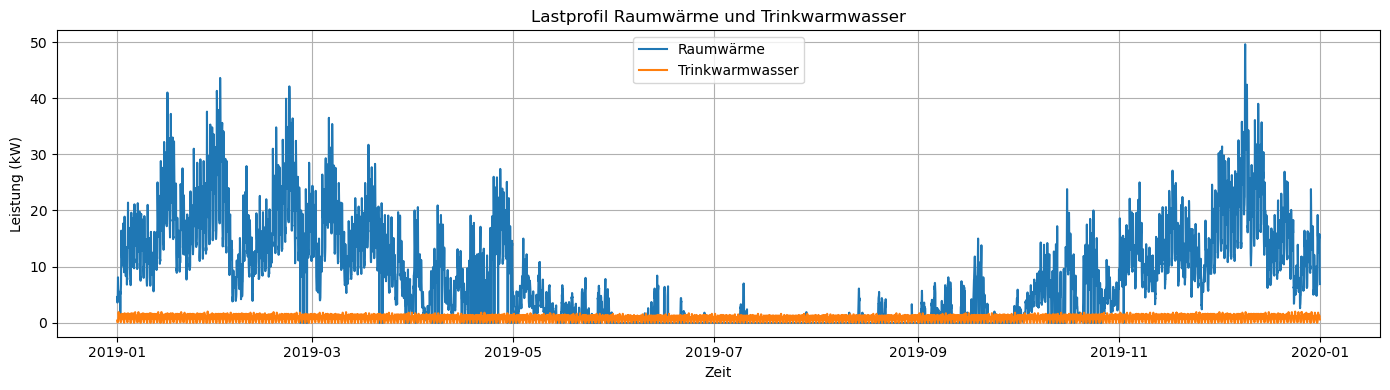

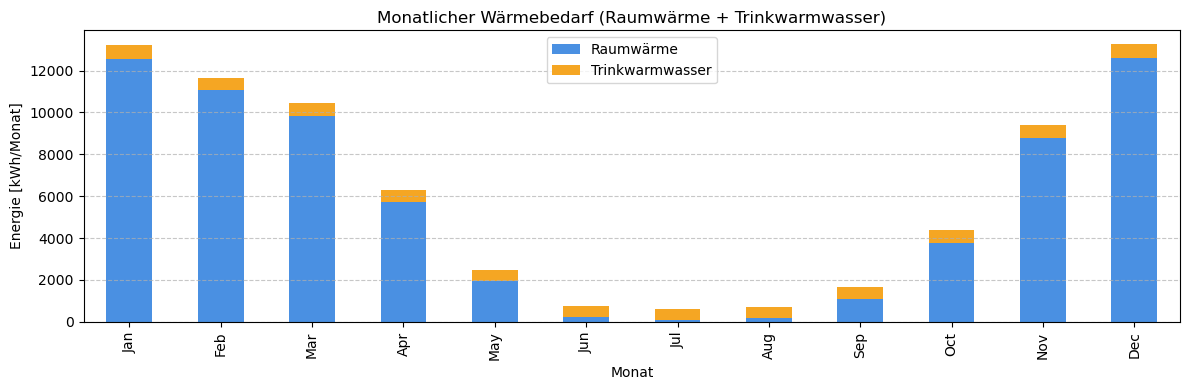

In [7]:
# ------------------------------------------------------------
# Plot der Lasten erstellen
# ------------------------------------------------------------

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Raumwaerme_(kW)"], label="Raumwärme")
plt.plot(df.index, df["Trinkwarmwasser_(kW)"], label="Trinkwarmwasser")

plt.legend()
plt.title("Lastprofil Raumwärme und Trinkwarmwasser")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Monats-Balkendiagramm: Raumwärme + Trinkwarmwasser
# ------------------------------------------------------------

# Monatsenergie berechnen (kWh/Monat bei 1h-Zeitschritt)
monthly_heat = df.resample("ME")[[
    "Raumwaerme_(kW)",
    "Trinkwarmwasser_(kW)"
]].sum()

# Monatsnamen hübsch
monthly_heat.index = monthly_heat.index.strftime("%b")

# Plot
ax = monthly_heat.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 4),
    color=["#4A90E2", "#F5A623"]  # Blau = Raumwärme, Orange = TWW
)

ax.set_title("Monatlicher Wärmebedarf (Raumwärme + Trinkwarmwasser)")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie [kWh/Monat]")
ax.legend(["Raumwärme", "Trinkwarmwasser"])
ax.grid(axis="y", alpha=0.7, linestyle="--")

plt.tight_layout()
plt.show()

In [8]:
# ------------------------------------------------------------
# PV Erzeugungsprofil laden
# ------------------------------------------------------------
# Annahmen: Dataset MERRA-2 (global), 2019, capacity 1kW, system loss 0.1 , Tilt 35°, Azimuth 180°, included raw data
pv = pd.read_csv(
    "../Input_Data/ninja_pv_50.9384_6.9600_corrected.csv",
    skiprows=3,
    parse_dates=["local_time"],
)

pv = pv.set_index("local_time")

pv = pv.rename(columns={
    "electricity": "pv_electricity",
    "irradiance_direct": "direct",
    "irradiance_diffuse": "diffuse",
    "temperature": "temp"
})

pv.head(100)

,time,pv_electricity,direct,diffuse,temp
local_time,,,,,
2019-01-01 01:00:00,2019-01-01 00:00,0.0,0.0,0.0,6.294
2019-01-01 02:00:00,2019-01-01 01:00,0.0,0.0,0.0,6.003
2019-01-01 03:00:00,2019-01-01 02:00,0.0,0.0,0.0,5.710
2019-01-01 04:00:00,2019-01-01 03:00,0.0,0.0,0.0,5.540
2019-01-01 05:00:00,2019-01-01 04:00,0.0,0.0,0.0,5.458
...,...,...,...,...,...
2019-01-05 00:00:00,2019-01-04 23:00,0.0,0.0,0.0,2.187
2019-01-05 01:00:00,2019-01-05 00:00,0.0,0.0,0.0,2.378
2019-01-05 02:00:00,2019-01-05 01:00,0.0,0.0,0.0,2.531


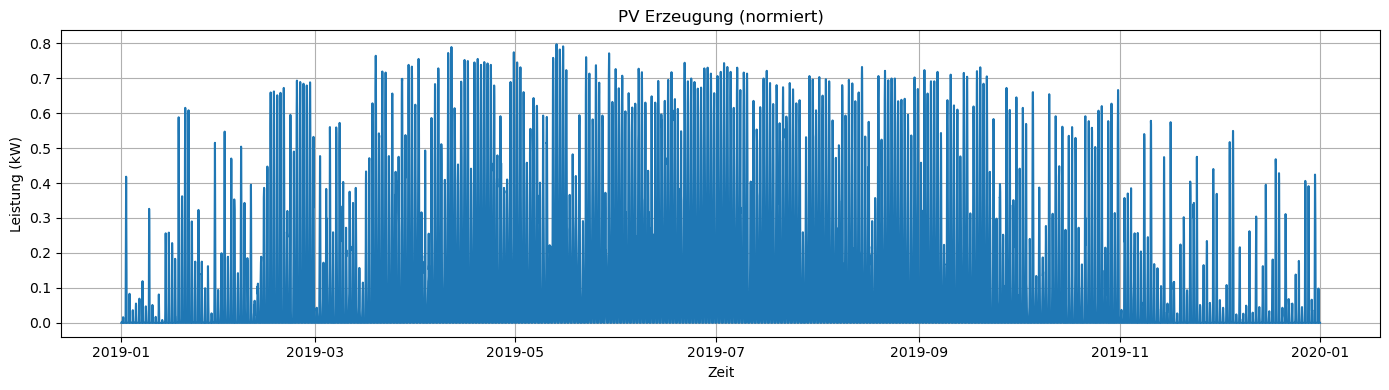

In [9]:
# ------------------------------------------------------------
# Erzeugungsprofil PV plotten
# ------------------------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(pv.index, pv["pv_electricity"], label="PV (kW)")
plt.title("PV Erzeugung (normiert)")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# ------------------------------------------------------------
# Strom Lastprofil laden
# ------------------------------------------------------------
# Annahme: 2-Personen-Haushalte für 6 Wohnungen = 12.000 kWh/a

df_strom = pd.read_csv(
    "../Input_Data/2026-01-24-Mehrfamilienhaus-Strom_Lastprofile.csv",
    sep=",",
    decimal="."
)

hh_last = df_strom["Strom gesamt (kW)"]  # kW

if not isinstance(hh_last.index, pd.DatetimeIndex):
    hh_last.index = pd.date_range("2019-01-01 00:00", periods=len(hh_last), freq="H")

hh_last.values


C:\Users\sarah\AppData\Local\Temp\ipykernel_2028\4025602395.py:15: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



array([0.9, 0.8, 0.7, ..., 2. , 1.9, 1.4])

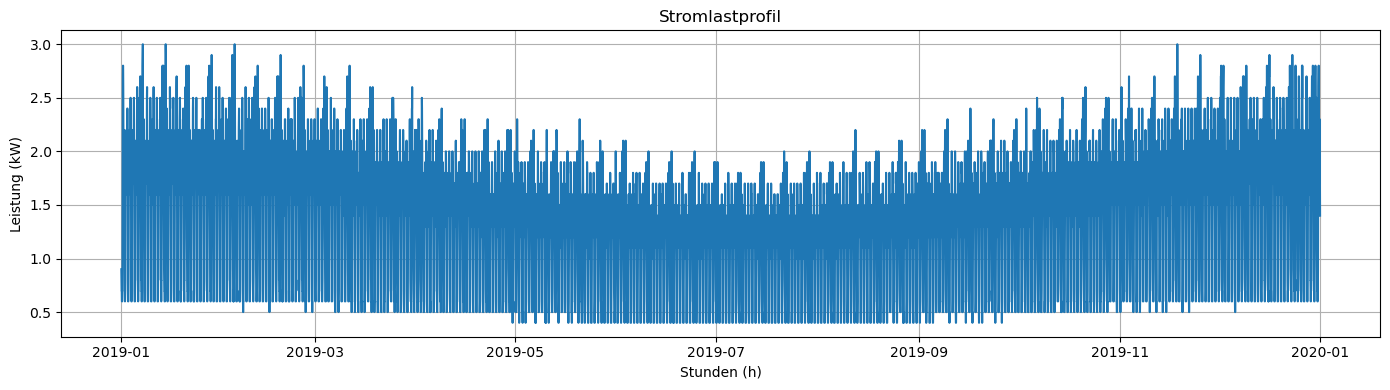

In [11]:
# ------------------------------------------------------------
# Stromlastprofil plotten
# ------------------------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(hh_last.index, hh_last, label="Stromlast (kW)")
plt.title("Stromlastprofil")
plt.xlabel("Stunden (h)")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# ------------------------------------------------------------
# Außentemperaturdaten laden
# ------------------------------------------------------------

weather = pd.read_csv(
    "../Input_Data/ninja_weather_50.9384_6.9600_2019_uncorrected.csv",
    skiprows=3,
    parse_dates=["local_time"]
)

# Index setzen
weather = weather.set_index("local_time")

# Umbenennen: t2m → T_outdoor
weather = weather.rename(columns={"t2m": "T_outdoor"})

# Nur Temperatur extrahieren
T_outdoor = weather["T_outdoor"]

T_outdoor.head()

local_time
2019-01-01 01:00:00    6.294
2019-01-01 02:00:00    6.003
2019-01-01 03:00:00    5.710
2019-01-01 04:00:00    5.540
2019-01-01 05:00:00    5.458
Name: T_outdoor, dtype: float64

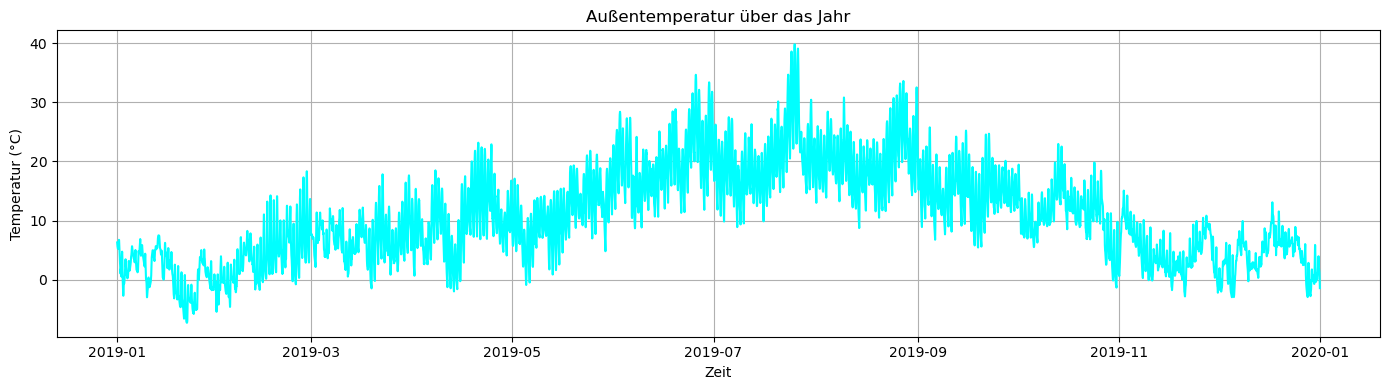

In [13]:
# -------------------------------------------
# Außentemperatur plotten
# -------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(weather.index, weather["T_outdoor"], label="Außentemperatur (°C)", color="cyan")

plt.title("Außentemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Vorlauftemperatur & Rücklauf (HK/FBH)

In [14]:
# ------------------------------------------------------------
# Heizkörper vs. Fußbodenheizung über Heizkurve (T_vorlauf, T_flow)
# ------------------------------------------------------------

# Flag: True = Heizkörper, False = Fußbodenheizung
use_radiators = False

# HK T_vorlauf = 45 - 55 °C; FBH T_Vorlauf = 30 - 35 °C
T_vorlauf = 51.0 if use_radiators else 33.0         # 51 °C bei 0°C ; bzw 33 bei 0°C (nach Quelle - 30°C bei -10°C bzw. - 55° bei -10°C)
T_gradient = 6/15 if use_radiators else 3/15        # wie stark die Vorlauftemperatur mit der Außentemp. steigt/fällt

# Heizkurve berechnen (PyPSA_heat-Funktion)
T_flow = ph.physics.flow_temperature(T_vorlauf, T_gradient, T_outdoor)

heating_cutoff = 15.0                          # °C Außentemperatur, ab der nicht mehr geheizt wird
heat_on = T_outdoor <= heating_cutoff
T_flow_min = 45 if use_radiators else 30       # Mindestvorlauftemperatur
T_flow = T_flow.clip(lower=T_flow_min)
T_flow = T_flow.where(heat_on, T_flow_min)

#Rücklauftemperatur vorgeben
delta_T = 10.0 if use_radiators else 5.0       # FBH hat geringere Rücklauftemperatur 
store_T_return  = T_flow_min - delta_T         # °C Rücklauftemperatur 35 HK und 25 FBH

store_T_return

25.0

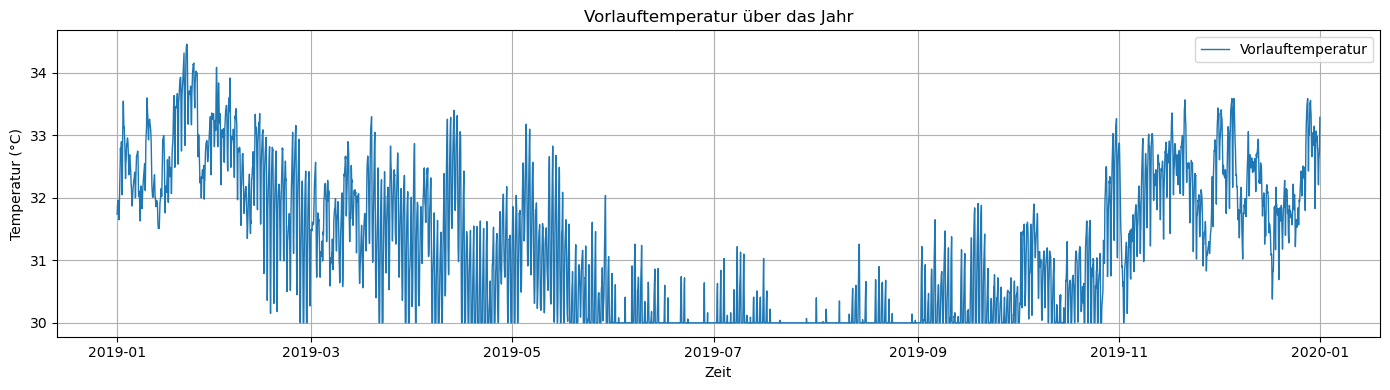

In [15]:
plt.figure(figsize=(14,4))
plt.plot(weather.index, T_flow, label="Vorlauftemperatur", linewidth=1)

plt.title("Vorlauftemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Komponentenparameter & Kosten

In [16]:
# --------------------------------
# Parametrisierung der Komponenten
# --------------------------------

#Strom Daten
grid_power      =   87        # kW Hausanschluss Leistung
grid_cost       =   0.372     # €/kWh Kosten für Netzstrombezug

interest_rate = 0.02

# PV - Daten
pv_invest       =   731       # €/kWp (einmalig)
pv_lifetime     =   20        # Jahre
PV_power        =   13        # kWp
feed_in_tariff  =   -0.0778   # €/kWh
pv_annuity = pv_invest * ((1+interest_rate)**pv_lifetime) * interest_rate / ((1+interest_rate)**pv_lifetime - 1)


#Wärmespeicher Daten
store_height    =   2.15      # m
store_base      =   0.708     # m²
# Volumen = store_base * store_height = 1.52 m³
store_u_wall    =   0.36      # W/(m²*K)
store_T_layers  =   [60, 55, 50, 45, 40] if use_radiators else [60, 55, 50, 45, 40, 35, 30]  #°C Temperaturschichten;
store_invest    =   1690      # €/kWh
store_lifetime  =   20        # Jahre
store_annuity   = store_invest * ((1+interest_rate)**store_lifetime) * interest_rate / ((1+interest_rate)**store_lifetime - 1)

# Heizstab
HE_power        =   9       # Heizstab-Nennleistung (kW)

# Wärmepumpe
HP_power        =    28     # WP-Nennleistung (kW_th)


### Energiesystem

In [17]:
# ------------------------------------------------------------
# Allgemeine Einstellungen des Networks
# ------------------------------------------------------------

snapshots = df.index   # DatetimeIndex aus deinem Lastgang (2019-01-01 ... 2019-12-31 23:00)

n = ph.HeatNetwork()
n.set_snapshots(snapshots)


# ------------------------------------------------------------
# Modellierung des Energiesystems
# ------------------------------------------------------------
# Busse
n.add("Bus", "electricity_grid")
n.add("Bus", "electricity_infeed")

# Grid import
n.add("Generator", "grid_import",
      bus="electricity_grid",
      p_nom=grid_power,
      marginal_cost=grid_cost)

# PV generation
n.add("Generator", "pv_generation",
      bus="electricity_infeed",
      p_nom=PV_power,
      p_max_pu=pv["pv_electricity"].values,
      capital_cost=pv_annuity)

# Strom einspeisen - export Generator
n.add("Generator", "pv_infeed",
      bus="electricity_infeed",
      p_nom=PV_power,                   # begrenzt die max. Exportleistung
      marginal_cost=feed_in_tariff,
      sign=-1)

# Link PV -> Hausnetz
n.add("Link", "electricity_link",
      bus0="electricity_infeed",
      bus1="electricity_grid",
      p_nom=PV_power,
      efficiency=1.0)

# Wärmespeicher
n.add("HeatStore", "hs_mfh",
      constant="temperature",
      height=store_height,
      base=store_base,
      T_layer=store_T_layers,
      T_return=store_T_return,
      V_initial=[0]*len(store_T_layers),
      cyclic=True,
      T_amb=18.0,
      U_wall=store_u_wall)

# Wärmepumpe (FIX p_nom)
n.add("HeatPump", "hp_mfh",
      bus0="electricity_grid",
      heat_store="hs_mfh",
      p_nom=HP_power,
      T_source=T_outdoor.values,
      T_max=65,
      heat_source="air")

# Heizstab
n.add("HeatingElement", "backup_heater",
      bus0="electricity_grid",
      heat_store="hs_mfh",
      p_nom=HE_power,
      efficiency=0.95)

# Elektrische Haushaltslast
n.add("Load", "el_demand",
      bus="electricity_grid",
      p_set=hh_last.values)

# HeatLoads
n.add("HeatLoad", "Raumwaerme",
      heat_store="hs_mfh",
      p_set=df["Raumwaerme_(kW)"].values,
      T_demand=T_flow.values)

n.add("HeatLoad", "dhw",
      heat_store="hs_mfh",
      p_set=df["Trinkwarmwasser_(kW)"].values,
      T_demand=60.0)

# ------------------------------------------------------------------
# System lösen
n.optimize(solver_name="gurobi")
# ------------------------------------------------------------------


C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dty

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2767106


INFO:gurobipy:Set parameter LicenseID to value 2767106


...

Solved in 122278 iterations and 4.24 seconds (2.69 work units)


INFO:gurobipy:Solved in 122278 iterations and 4.24 seconds (2.69 work units)


Optimal objective  8.406432678e+03


INFO:gurobipy:Optimal objective  8.406432678e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 227760 primals, 438000 duals
Objective: 8.41e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, HeatStore-hs_mfh-fix-volume-upper, HeatStore-hs_mfh-fix-volume-lower, HeatStore-hs_mfh-layer_balance, HeatStore-hs_mfh-internal-lower, HeatingElement-backup_heater-fix-p-lower, HeatingElement-backup_heater-fix-p-upper, HeatPump-hp_mfh-fix-p-lower, HeatPump-hp_mfh-fix-p-upper, HeatPump-hp_mfh-fix-p-layer-lower, HeatPump-hp_mfh-fix-p-layer-upper were not assigned to the network.


PyPSA Heat Network
Components:
 - Bus: 2
 - Generator: 3
 - Link: 1
 - Load: 1
 - HeatLoad: 2
 - HeatPump: 1
 - HeatStore: 1
 - HeatingElement: 1
Snapshots: 8760

### Energiesystem: Ergebnisse & Kennzahlen

#### Wärmespeicher


================ Wärmespeicher Summary ================
HS: hs_mfh | Vtot=1.522 m³ (H=2.15 m, A=0.708 m²)
T_layer: [30, 35, 40, 45, 50, 55, 60] °C | T_return: 25 °C

        Schicht  Volumen über Jahr [m³·h] Anteil an Jahresnutzung [%] Aktive Stunden [h/a] (V > 0) Volumen über Jahr [m³]
T_return (25°C)               6364.286162                       47,73                      6500,00                 6364,3
           30°C                  8.341919                        0,06                      2837,00                    8,3
           35°C               2543.743724                       19,08                      5065,00                 2543,7
           40°C                265.680695                        1,99                      5338,00                  265,7
           45°C                375.169817                        2,81                      5807,00                  375,2
           50°C                289.138570                        2,17                      6115,00   

C:\Users\sarah\AppData\Local\Temp\ipykernel_2028\3690398079.py:40: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



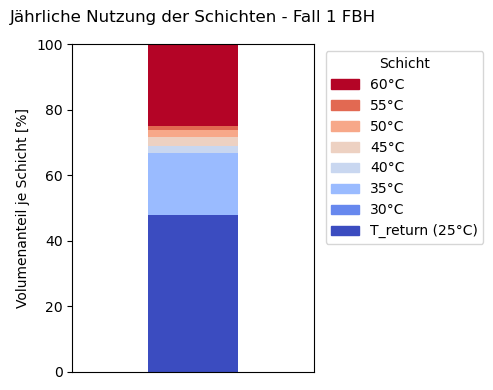

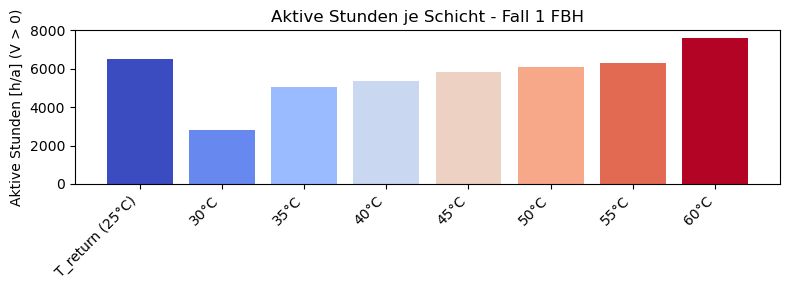

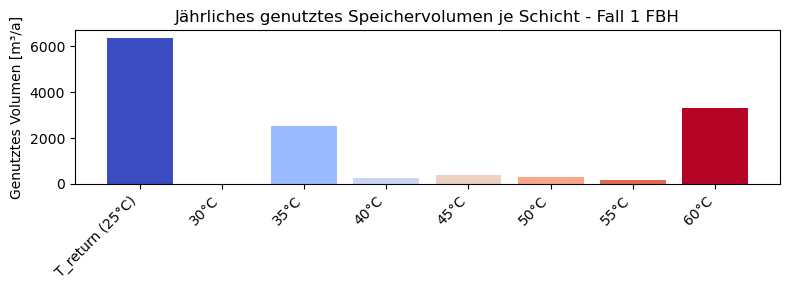

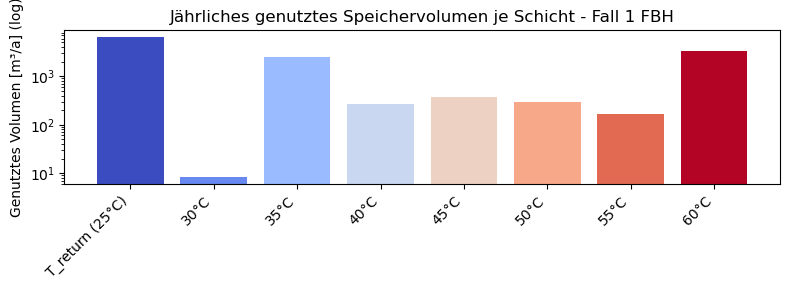

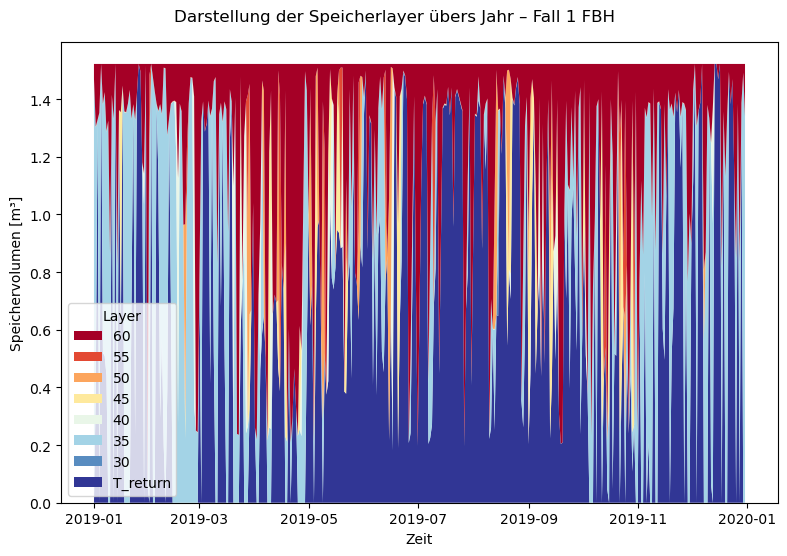

In [18]:
hs = "hs_mfh"

# ---------- Parameter ----------
H = float(n.heat_stores.loc[hs, "height"])
A = float(n.heat_stores.loc[hs, "base"])
Vtot = H * A                                                     # Gesamt Speichervolumen

T_layers = np.array(n.heat_stores.loc[hs, "T_layer"], float)
T_return = float(n.heat_stores.loc[hs, "T_return"])

V_layers = n.heat_stores_t["V_layer"][hs]
V_return_ts = (Vtot - V_layers.sum(axis=1)).clip(lower=0.0)

# kalt -> heiß
order = np.argsort(T_layers)
T_sorted = T_layers[order]
V_sorted = V_layers.iloc[:, order]

# ---------- Kennzahlen ----------

year_V_layers = V_sorted.sum(axis=0).values      # m³·h
year_V_return = V_return_ts.sum()                # m³·h

year_total = year_V_layers.sum() + year_V_return

share_layers_pct = year_V_layers / year_total * 100
share_return_pct = year_V_return / year_total * 100

active_layers_h = (V_sorted > 0).sum(axis=0)                # Anzahl aktiver Schichten; z.B.: "Schicht X °C war 4200 Stunden aktiv"
active_return_h = int((V_return_ts > 0).sum())              # Stunden des Rücklaufs im Jahr aktiv; aktiv = V>0 !

labels = [f"T_return ({T_return:.0f}°C)"] + [f"{t:.0f}°C" for t in T_sorted]

year_m3h = np.r_[year_V_return, year_V_layers]
year_V = np.r_[year_V_return, year_V_layers]
share_pct = np.r_[share_return_pct, share_layers_pct]
active_h = np.r_[active_return_h, active_layers_h]

# ---------- Farben kalt->heiß ----------
cmap = cm.get_cmap("coolwarm")
temps_for_colors = np.r_[T_return, T_sorted]
norm = (temps_for_colors - temps_for_colors.min()) / (temps_for_colors.max() - temps_for_colors.min() + 1e-12)
colors = cmap(norm)

# ---------- Tabelle mit Daten  ----------
df = pd.DataFrame({
    "Schicht": labels,
    "Volumen über Jahr [m³·h]": year_m3h,
    "Anteil an Jahresnutzung [%]": share_pct,
    "Aktive Stunden [h/a] (V > 0)": active_h
})

df_print = df.copy()
df_print["Volumen über Jahr [m³]"] = df_print["Volumen über Jahr [m³·h]"].map(lambda x: f"{x:.1f}".replace(".", ","))
df_print["Anteil an Jahresnutzung [%]"] = df_print["Anteil an Jahresnutzung [%]"].map(lambda x: f"{x:.2f}".replace(".", ","))
df_print["Aktive Stunden [h/a] (V > 0)"] = df_print["Aktive Stunden [h/a] (V > 0)"].map(lambda x: f"{x:.2f}".replace(".", ","))


print("\n================ Wärmespeicher Summary ================")
print(f"HS: {hs} | Vtot={Vtot:.3f} m³ (H={H:.2f} m, A={A:.3f} m²)")
print(f"T_layer: {list(map(int, T_sorted))} °C | T_return: {T_return:.0f} °C")
print("======================================================\n")
print(df_print.to_string(index=False))

print(f"\nSanity: Summe Anteile = {df['Anteil an Jahresnutzung [%]'].sum():.2f}%")


# ---------- Plot 1: Jahresauswertung gestapelt (Volumenanteile) ----------
fig, ax = plt.subplots(figsize=(5,4))
bottom = 0.0
for lab, val, col in zip(labels, share_pct, colors):
    ax.bar(0, val, bottom=bottom, color=col, width=0.6, edgecolor="none")
    bottom += val

ax.set_xlim(-0.8, 0.8)
ax.set_xticks([])
ax.set_ylim(0, 100)
ax.set_ylabel("Volumenanteil je Schicht [%]")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in colors[::-1]]
ax.legend(handles, labels[::-1], title="Schicht", bbox_to_anchor=(1.02,1), loc="upper left")
plt.title("Jährliche Nutzung der Schichten - Fall 1 FBH", pad=16)
plt.tight_layout()
plt.show()

# ---------- Plot 2: Aktivität je Schicht ----------
plt.figure(figsize=(8,3))
plt.bar(labels, active_h, color=colors, edgecolor="none")
plt.ylabel("Aktive Stunden [h/a] (V > 0)")
plt.title("Aktive Stunden je Schicht - Fall 1 FBH")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------- Plot 2.1: genutztes Volumen je Schicht im jahr ----------
plt.figure(figsize=(8,3))
plt.bar(labels, year_V, color=colors, edgecolor="none")
plt.ylabel("Genutztes Volumen [m³/a]")
plt.title("Jährliches genutztes Speichervolumen je Schicht - Fall 1 FBH")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------- Plot: genutztes Volumen je Schicht (log y) ----------
eps = 1e-3  # kleines Volumen für log-Darstellung
year_V_plot = np.maximum(year_V, eps)

plt.figure(figsize=(8,3))
plt.bar(labels, year_V_plot, color=colors, edgecolor="none")
plt.yscale("log")
plt.ylabel("Genutztes Volumen [m³/a] (log)")
plt.title("Jährliches genutztes Speichervolumen je Schicht - Fall 1 FBH")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ---------- Plot 3: pypsaheat Zeitplot (dein Standard) ----------
sns_to_plot = n.snapshots[::24]
ph.plot.plot_stratified_heat_store(n, hs=hs, sns=sns_to_plot)

fig = plt.gcf()
ax = plt.gca()

fig.suptitle(
    "Darstellung der Speicherlayer übers Jahr – Fall 1 FBH",
    y=0.92
)

ax.set_ylabel("Speichervolumen [m³]")
ax.set_xlabel("Zeit")

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

#### Wärmepumpe – Betrieb, COP & JAZ


Wärmepumpe – Auswertung (hp_mfh)


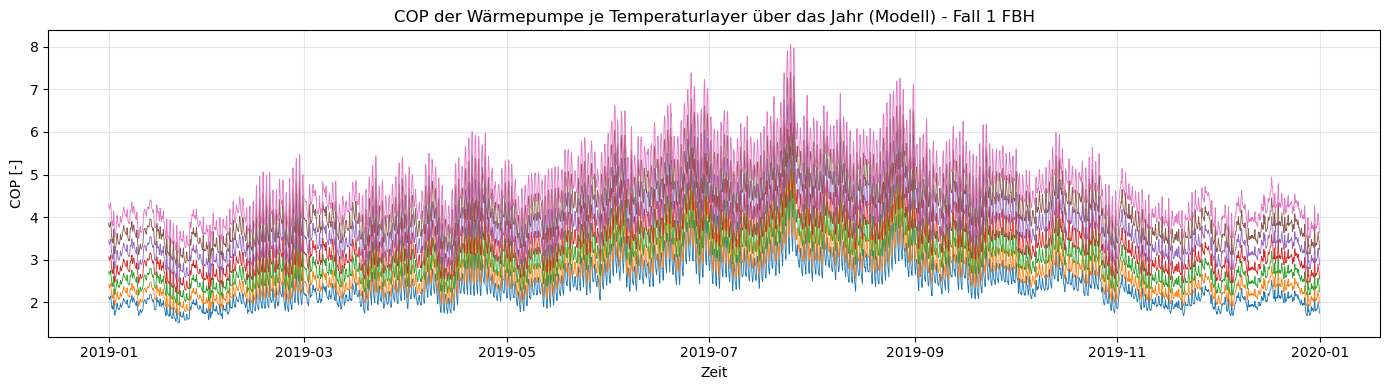


--- Auslegung ---
Thermische Nennleistung p_nom: 28.00 kW_th

--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---
COP Mittelwert: 3.74
COP Median:     3.69
COP Minimum:    1.96
COP Maximum:    7.88

--- Jahresenergien ---
WP Stromverbrauch: 21321.10 kWh_el/a
WP Wärmeerzeugung: 75140.30 kWh_th/a

--- JAZ ---
JAZ_HP (Q_hp / E_hp): 3.524


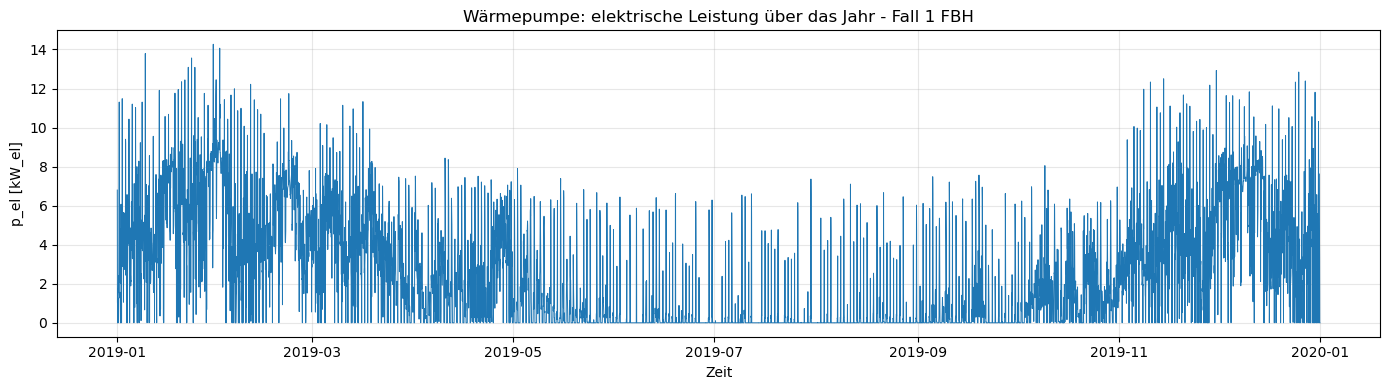

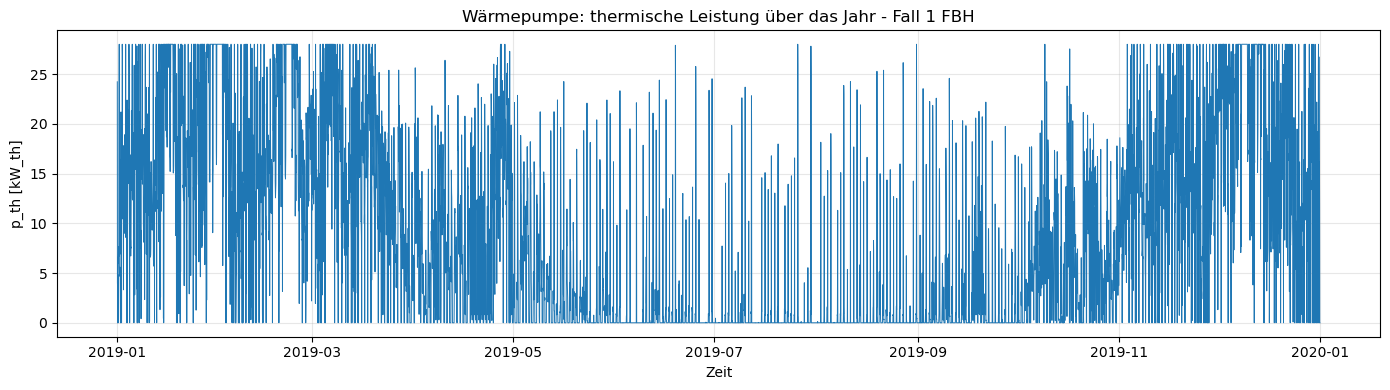

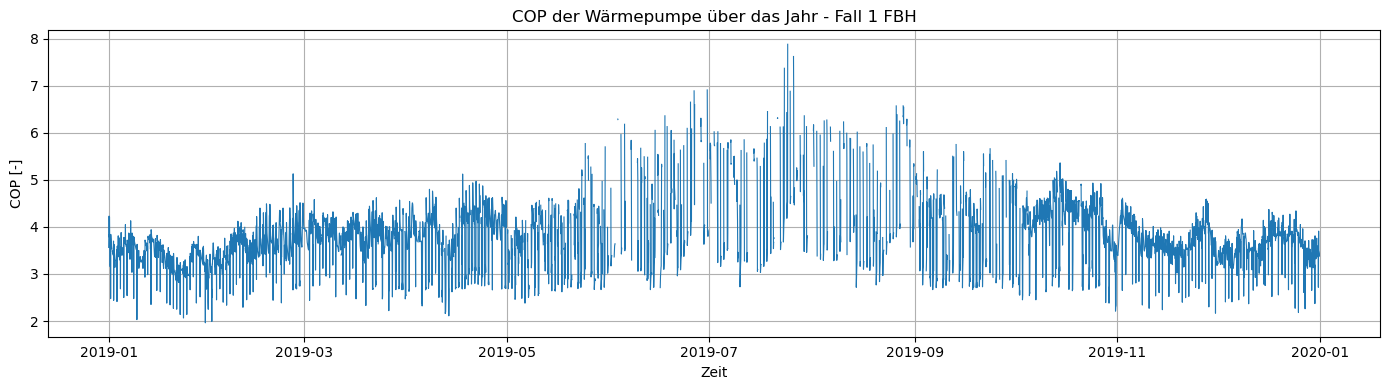

Index(['bus0', 'heat_store', 'type', 'carrier', 'p_nom', 'm_nom', 'T_source',
       'T_nom', 'T_max', 'COP_model', 'heat_source'],
      dtype='object', name='attribute')
attribute
bus0           electricity_grid
heat_store               hs_mfh
type                           
carrier                        
p_nom                      28.0
m_nom                       0.0
T_source                    0.0
T_nom                      60.0
T_max                      65.0
COP_model                   0.0
heat_source                 air
Name: hp_mfh, dtype: object


In [19]:
# ============================================================
# Wärmepumpe (hp_mfh): Kennzahlen, COP-Verlauf, JAZ
# ============================================================

hp_name = "hp_mfh"
hp_df = n.df("HeatPump")        # Tabelle Parameter HP
hp_t  = n.pnl("HeatPump")       # Zeitreihen-Container pro Std. für HP (p_heat, p_elec, COP)

print("\n====================================")
print(f"Wärmepumpe – Auswertung ({hp_name})")
print("====================================")

# --- Modellergebnisse der WP  ---
cop_model  = hp_t["COP"][hp_name]         # kommt aus unserem Model und kann mehere Temperaturschichten bedienen
p_el_model = hp_t["p_elec"][hp_name]      # p_el_model = elektrische Leistung der WP
p_th_model = hp_t["p_heat"][hp_name]      # p_th_model = thermische Leistung der WP

# ============================================================
# Extra Plot: COP je Temperaturschicht darstellen
# ============================================================

plt.figure(figsize=(14,4))

if isinstance(cop_model, pd.DataFrame):
    # Mehrere Temperaturlayer → jede Spalte wird eine Linie
    plt.plot(cop_model.index, cop_model.values, linewidth=0.6)
    plt.title("COP der Wärmepumpe je Temperaturlayer über das Jahr (Modell) - Fall 1 FBH")
else:
    # Nur ein Layer
    plt.plot(cop_model.index, cop_model.values, linewidth=0.8)
    plt.title("COP der Wärmepumpe über das Jahr (Modell) - Fall 1 FBH")

plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# ============================================================


# --- Zeitindex (für Plot & Resample) ---
time_index = n.snapshots


p_th_total = p_th_model.sum(axis=1) if isinstance(p_th_model, pd.DataFrame) else p_th_model
p_el_total = p_el_model.sum(axis=1) if isinstance(p_el_model, pd.DataFrame) else p_el_model

# optional: Modell-COP als Mittel (nur Info)
cop_model_mean = cop_model.mean(axis=1) if isinstance(cop_model, pd.DataFrame) else cop_model

p_el_ts = pd.Series(np.asarray(p_el_total, dtype=float), index=time_index)
p_th_ts = pd.Series(np.asarray(p_th_total, dtype=float), index=time_index)
cop_model_ts = pd.Series(np.asarray(cop_model_mean, dtype=float), index=time_index)

# COP berechnung aus Q/P
cop_phys_ts = p_th_ts / p_el_ts.replace(0, np.nan)

# --- Auslegung ---
P_th_nom_val = float(hp_df.loc[hp_name, "p_nom"]) if "p_nom" in hp_df.columns else None
print("\n--- Auslegung ---")
if P_th_nom_val is not None:
    print(f"Thermische Nennleistung p_nom: {P_th_nom_val:.2f} kW_th")

# --- Kennzahlen (COP der WP) ---
COP_mean   = float(np.nanmean(cop_phys_ts.values))      # Durchschnittlicher Betriebs-COP
COP_median = float(np.nanmedian(cop_phys_ts.values))    # Median-Betriebs-COP
COP_min    = float(np.nanmin(cop_phys_ts.values))       # Schlechtester Betriebszustand
COP_max    = float(np.nanmax(cop_phys_ts.values))       # Bester Betriebszustand

print("\n--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---")
print(f"COP Mittelwert: {COP_mean:.2f}")
print(f"COP Median:     {COP_median:.2f}")
print(f"COP Minimum:    {COP_min:.2f}")
print(f"COP Maximum:    {COP_max:.2f}")

# --- Jahresenergien ---
E_hp = float(np.nansum(p_el_ts.values))  # kWh_el/a
Q_hp = float(np.nansum(p_th_ts.values))  # kWh_th/a

print("\n--- Jahresenergien ---")
print(f"WP Stromverbrauch: {E_hp:.2f} kWh_el/a")
print(f"WP Wärmeerzeugung: {Q_hp:.2f} kWh_th/a")

# --- JAZ Berechnung ---
print("\n--- JAZ ---")
JAZ_hp = (Q_hp / E_hp) if E_hp > 0 else np.nan
print(f"JAZ_HP (Q_hp / E_hp): {JAZ_hp:.3f}")


# ============================================================
# --- Ergebnis Plots:  ---
# ============================================================
# Wärmepumpe: elektrische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_el_ts.index, p_el_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: elektrische Leistung über das Jahr - Fall 1 FBH")
plt.xlabel("Zeit")
plt.ylabel("p_el [kW_el]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: thermische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_th_ts.index, p_th_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: thermische Leistung über das Jahr - Fall 1 FBH")
plt.xlabel("Zeit")
plt.ylabel("p_th [kW_th]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: Betriebs COP über das Jahr
plt.figure(figsize=(14,4))
plt.plot(cop_phys_ts.index, cop_phys_ts.values, linewidth=0.8, label="COP phys (Q/P)")
plt.title("COP der Wärmepumpe über das Jahr - Fall 1 FBH")
plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True)
plt.tight_layout()
plt.show()

hp_df = n.df("HeatPump")
print(hp_df.columns)
print(hp_df.loc["hp_mfh"])


#### Heizstab – Betrieb & Jahresenergie

heating_elements_t keys: ['p', 'p_heat', 'p_elec']

--- Peaks ---
max p_heat [kW]: 8.549999999999999
max p_elec [kW]: 9.0


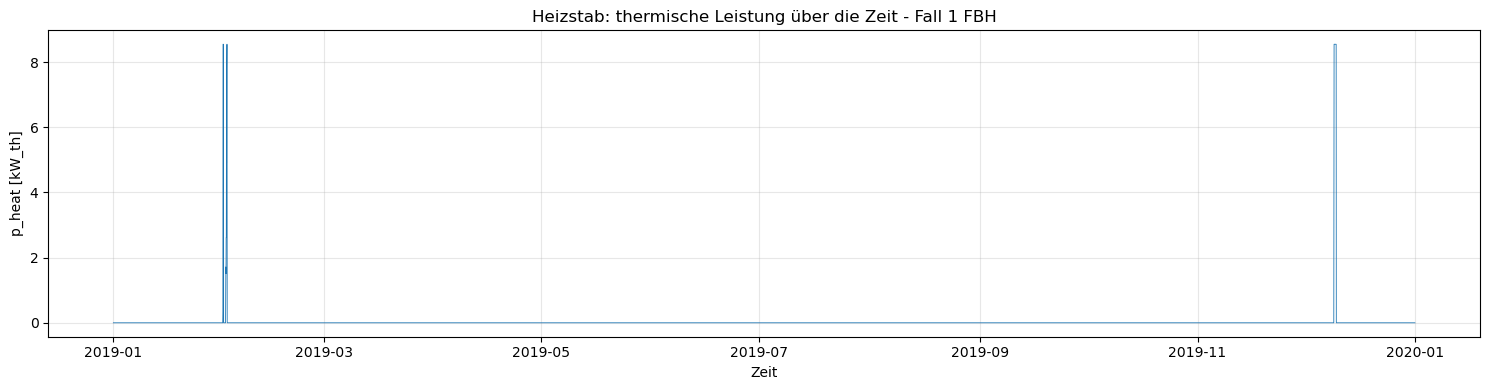

In [20]:
# ---------------------------------------
# Heizstab-Auswertung (backup_heater)
# ---------------------------------------

name = "backup_heater"

# verfügbare Keys anschauen
print("heating_elements_t keys:", list(n.heating_elements_t.keys()))

# helper: erste passende Zeitreihe nehmen
def get_ts(d, candidates):
    for c in candidates:
        if c in d:
            return d[c]
    raise KeyError(f"Keiner der Keys {candidates} in heating_elements_t vorhanden.")

# Kandidaten für "thermische Leistung" und "elektrische Leistung"
heat_key = get_ts(n.heating_elements_t, ["p_heat", "p1", "p_out", "p"])
elec_key = get_ts(n.heating_elements_t, ["p_elec", "p0", "p_in"])

# Das sind DataFrames → Spalte auswählen
p_heat = heat_key[name]
p_elec = elec_key[name]

print("\n--- Peaks ---")
print("max p_heat [kW]:", float(p_heat.max()))
print("max p_elec [kW]:", float(p_elec.max()))

# Plot
plt.figure(figsize=(15,4))
plt.plot(p_heat.index, p_heat.values, linewidth=0.6)
plt.title("Heizstab: thermische Leistung über die Zeit - Fall 1 FBH")
plt.xlabel("Zeit")
plt.ylabel("p_heat [kW_th]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Deckungsanteile Wärmeerzeuger (WP vs. Heizstab)

In [21]:
# ============================================================
# Deckungsanteile Wärmeerzeuger (WP vs. Heizstab)
# ============================================================

# Heizstab: Jahreswärme
Q_he = float(np.nansum(p_heat.values))   # kWh_th/a

# WP: Jahreswärme (hast du schon)
Q_wp = float(Q_hp)                       # kWh_th/a

Q_total = Q_wp + Q_he

wp_share = (Q_wp / Q_total) * 100 if Q_total > 0 else np.nan
he_share = (Q_he / Q_total) * 100 if Q_total > 0 else np.nan

print("\n====================================")
print("Deckungsanteile Wärmeerzeugung")
print("====================================")
print(f"Wärmepumpe: {wp_share:.2f} %")
print(f"Heizstab:   {he_share:.2f} %")
print(f"Gesamtwärme: {Q_total:.0f} kWh_th/a")



Deckungsanteile Wärmeerzeugung
Wärmepumpe: 99.72 %
Heizstab:   0.28 %
Gesamtwärme: 75354 kWh_th/a


#### Strombilanz


--- Strombilanz ---
Verbrauch gesamt (HH+WP+HE):           33546 kWh/a
Netzbezug:                             23763 kWh/a
PV-Erzeugung:                          15355 kWh/a
Einspeisung (Export):                  -5572 kWh/a
Autarkiegrad:                          29.2 %


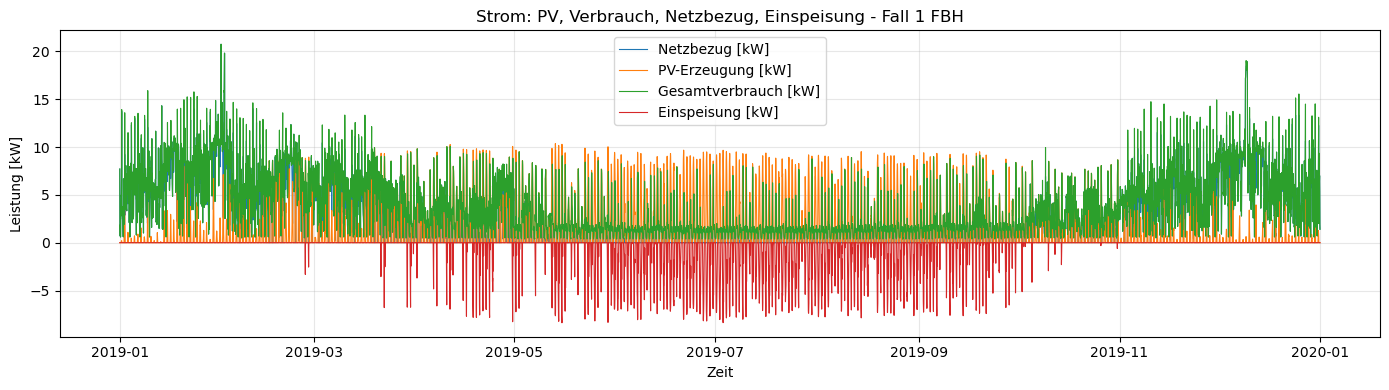

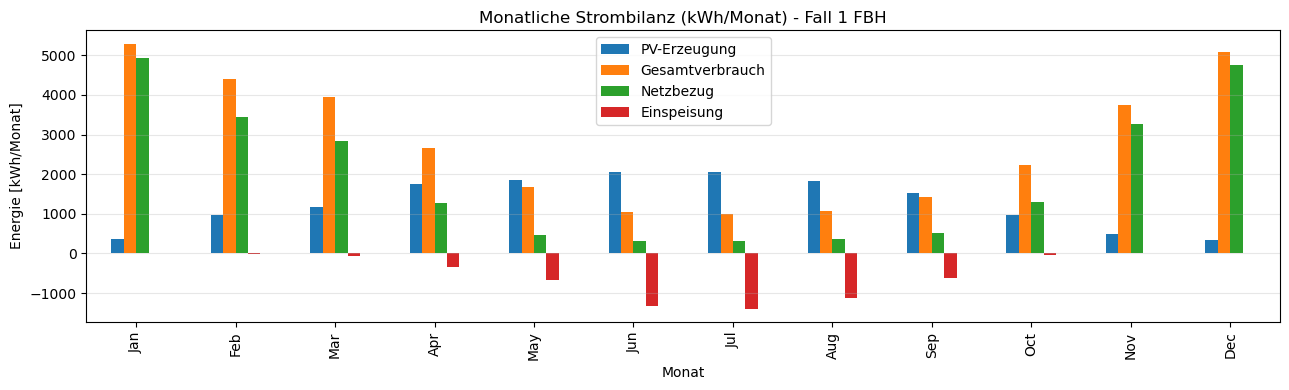

In [22]:
# ================================
#  ## - Netzbezug - PV Gen. - Einspeisung etc.
# ================================
time_index = n.snapshots

# --- 1) PV generation (kW) ---
pv_gen = n.generators_t.p["pv_generation"]     # kW, >=0

# --- 2) Grid import (kW) ---
grid_import = n.generators_t.p["grid_import"]  # kW, >=0

# --- 3) Feed-in / export (kW, make it positive) ---
if "pv_infeed" in n.generators_t.p.columns:
    export = -n.generators_t.p["pv_infeed"]    # kW, >=0
else:
    export = pd.Series(0.0, index=n.snapshots)

# --- 4) Household electric load (kW) ---
load_el = n.loads_t.p["el_demand"]  # kW

# --- 5) Heat pump electric consumption (kW) ---
hp_t = n.pnl("HeatPump")
hp_p_el = hp_t["p_elec"]["hp_mfh"]
hp_p_el_total = hp_p_el.sum(axis=1) if isinstance(hp_p_el, pd.DataFrame) else hp_p_el  # kW

# --- 6) Heating element electric consumption (kW) ---
he_t = n.pnl("HeatingElement")
he_p_el = he_t["p_elec"]["backup_heater"]
he_p_el_total = he_p_el.sum(axis=1) if isinstance(he_p_el, pd.DataFrame) else he_p_el  # kW


# --- Total electric consumption on the grid bus (kW) ---
# This is what must be covered by PV (via link), and grid import.
total_consumption = load_el + hp_p_el_total + he_p_el_total

# --- Energies (kWh) for hourly data: sum of kW values ---
E_grid = float(grid_import.sum())
E_cons = float(total_consumption.sum())
E_pv = float(pv_gen.sum())
E_exp = float(export.sum())

autarkiegrad = 1 - (E_grid / E_cons) if E_cons > 0 else np.nan

print("\n--- Strombilanz ---")
print(f"Verbrauch gesamt (HH+WP+HE):           {E_cons:.0f} kWh/a")
print(f"Netzbezug:                             {E_grid:.0f} kWh/a")
print(f"PV-Erzeugung:                          {E_pv:.0f} kWh/a")
print(f"Einspeisung (Export):                  {E_exp:.0f} kWh/a")
print(f"Autarkiegrad:                          {autarkiegrad*100:.1f} %")

# --- Plot: power time series ---
plt.figure(figsize=(14,4))
plt.plot(time_index, grid_import.values, label="Netzbezug [kW]", linewidth=0.8)
plt.plot(time_index, pv_gen.values, label="PV-Erzeugung [kW]", linewidth=0.8)
plt.plot(time_index, total_consumption.values, label="Gesamtverbrauch [kW]", linewidth=0.8)
plt.plot(time_index, export.values, label="Einspeisung [kW]", linewidth=0.8)
plt.title("Strom: PV, Verbrauch, Netzbezug, Einspeisung - Fall 1 FBH")
plt.xlabel("Zeit")
plt.ylabel("Leistung [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Monthly energy bars (kWh/month) ---
pv_ts   = pd.Series(pv_gen.to_numpy(), index=time_index)
cons_ts = pd.Series(total_consumption.to_numpy(), index=time_index)
imp_ts  = pd.Series(grid_import.to_numpy(), index=time_index)
exp_ts  = pd.Series(export.to_numpy(), index=time_index)

monthly = pd.DataFrame({
    "PV-Erzeugung":     pv_ts.resample("ME").sum(),
    "Gesamtverbrauch": cons_ts.resample("ME").sum(),
    "Netzbezug":       imp_ts.resample("ME").sum(),
    "Einspeisung":            exp_ts.resample("ME").sum(),
})
monthly.index = monthly.index.strftime("%b")

ax = monthly.plot(kind="bar", figsize=(13,4))
ax.set_title("Monatliche Strombilanz (kWh/Monat) - Fall 1 FBH")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie [kWh/Monat]")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



In [23]:
# ============================================================
# PV-Deckung der Wärmepumpe (WP)
# ============================================================
 
# PV -> Hausnetz (kW) über den Link
pv_to_house = n.links_t.p0["electricity_link"]  # Leistung auf bus0-Seite (infeed -> grid), i.d.R. >=0
 
# Gesamtzufluss ins Hausnetz (kW): Netz + PV
total_inflow = grid_import + pv_to_house
 
# Anteil PV am Hausnetz (zeitabhängig)
pv_share_gridbus = (pv_to_house / total_inflow.replace(0, np.nan)).clip(0, 1).fillna(0)
 
# WP-Strom (kW)
wp_el = hp_p_el_total
 
# WP-Strom aus PV (kW) als Proxy über Quellenmix
wp_from_pv = wp_el * pv_share_gridbus
 
E_wp = float(wp_el.sum())
E_wp_pv = float(wp_from_pv.sum())
E_wp_grid = E_wp - E_wp_pv
 
print("\n--- PV-Deckung Wärmepumpe ---")
print(f"WP Strom gesamt:     {E_wp:.0f} kWh/a")
print(f"WP Strom aus PV:     {E_wp_pv:.0f} kWh/a ({(E_wp_pv/E_wp*100 if E_wp>0 else 0):.1f} %)")
print(f"WP Strom aus Netz:   {E_wp_grid:.0f} kWh/a")
 
# ============================================================
# Kosteneinsparung durch PV-Nutzung der Wärmepumpe
# ============================================================
 
strompreis_grid = grid_cost                 # €/kWh
strompreis_pv   = abs(feed_in_tariff)       # €/kWh (entgangene Einspeisung)
 
# Kosten, wenn WP komplett aus Netz versorgt würde
cost_wp_grid_only = E_wp * strompreis_grid
 
# Tatsächliche Kosten mit PV-Anteil
cost_wp_real = (
    E_wp_grid * strompreis_grid +
    E_wp_pv   * strompreis_pv
)
 
savings_wp_pv = cost_wp_grid_only - cost_wp_real
 
print("\n--- Kosteneffekt PV → Wärmepumpe ---")
print(f"Kosten WP (nur Netz):        {cost_wp_grid_only:.2f} € / a")
print(f"Kosten WP (mit PV-Anteil):   {cost_wp_real:.2f} € / a")
print(f"Ersparnis durch PV-Nutzung:  {savings_wp_pv:.2f} € / a")


--- PV-Deckung Wärmepumpe ---
WP Strom gesamt:     21321 kWh/a
WP Strom aus PV:     5585 kWh/a (26.2 %)
WP Strom aus Netz:   15736 kWh/a

--- Kosteneffekt PV → Wärmepumpe ---
Kosten WP (nur Netz):        7931.45 € / a
Kosten WP (mit PV-Anteil):   6288.20 € / a
Ersparnis durch PV-Nutzung:  1643.25 € / a


#### Wärmegestehungskosten Berechnung

In [24]:
# ============================================================
# LCOH_heat_total: Raumwärme (WP+HE) + DHW (DLE)
# ============================================================

dt_h = 1.0  # Stundenauflösung

# ---------- 1) Wärmemengen (kWh_th/a) ----------
Q_space_wp = float(Q_hp)      # kWh_th/a
Q_space_he = float(Q_he)      # kWh_th/a

Q_heat_total = Q_space_wp + Q_space_he

# ---------- 2) Strommengen der Wärmeerzeuger (kWh_el/a) ----------
# WP elektrisch
E_wp_total = float(E_hp)  # kWh_el/a

# Heizstab elektrisch: aus p_elec (kW_el) über's Jahr summieren
E_he_total = float(np.nansum(p_elec.values))  # kWh_el/a


# ---------- 3) PV-Anteile (Proxy über Mix am Grid-Bus) ----------

E_wp_pv   = float((hp_p_el_total * pv_share_gridbus).sum())
E_wp_grid = E_wp_total - E_wp_pv

E_he_pv   = float((he_p_el_total * pv_share_gridbus).sum())
E_he_grid = E_he_total - E_he_pv

# ---------- 4) Wärmerelevante CAPEX (€/a) ----------
# Wenn (noch) keine CAPEX für WP/HE/Store/DLE, bleibt das 0.
capex_heat = 0.0

# ---------- 5) Variable Wärmekosten (€/a) ----------
cost_grid = grid_cost
cost_pv   = abs(feed_in_tariff)   # Opportunitätskosten PV-Nutzung

opex_heat = (
    E_wp_grid  * cost_grid + E_wp_pv  * cost_pv +
    E_he_grid  * cost_grid + E_he_pv  * cost_pv
)

total_heat_costs = capex_heat + opex_heat

# ---------- 6) LCOH ----------
LCOH_heat_total = total_heat_costs / Q_heat_total if Q_heat_total > 0 else np.nan

print("\n================= HEAT-LCOH (inkl. DHW/DLE) =================")
print(f"Q_space (WP+HE): {Q_space_wp + Q_space_he:,.1f} kWh_th/a")
print(f"Q_heat_total:    {Q_heat_total:,.1f} kWh_th/a")
print("--------------------------------------------------------------")
print(f"E_wp_total:      {E_wp_total:,.1f} kWh_el/a (PV {E_wp_pv:,.1f} | Grid {E_wp_grid:,.1f})")
print(f"E_he_total:      {E_he_total:,.1f} kWh_el/a (PV {E_he_pv:,.1f} | Grid {E_he_grid:,.1f})")

print("--------------------------------------------------------------")
print(f"CAPEX_heat:      {capex_heat:,.2f} € / a")
print(f"OPEX_heat:       {opex_heat:,.2f} € / a")
print(f"TOTAL_heat:      {total_heat_costs:,.2f} € / a")
print(f"LCOH_heat_total: {LCOH_heat_total:.4f} € / kWh_th")
print("==============================================================\n")



# ============================================================
# 2) SYSTEMKOSTEN GESAMT (INFO): inkl. Nutzerstrom etc.
#    -> NICHT für LCOH, nur report
# ============================================================

system_cost_total = float(n.objective)  # was dein Optimierer minimiert
system_capex_total = float(n.statistics.capex().sum())
system_opex_total  = float(n.statistics.opex().sum())

print("\n================= SYSTEMKOSTEN (INFO) =================")
print(f"System TOTAL (objective): {system_cost_total:,.2f} € / a")
print(f"System CAPEX:            {system_capex_total:,.2f} € / a")
print(f"System OPEX:             {system_opex_total:,.2f} € / a")
print("=======================================================\n")




================= HEAT-LCOH (inkl. DHW/DLE) =================
Q_space (WP+HE): 75,353.9 kWh_th/a
Q_heat_total:    75,353.9 kWh_th/a
--------------------------------------------------------------
E_wp_total:      21,321.1 kWh_el/a (PV 5,585.5 | Grid 15,735.6)
E_he_total:      224.9 kWh_el/a (PV 2.4 | Grid 222.5)
--------------------------------------------------------------
CAPEX_heat:      0.00 € / a
OPEX_heat:       6,371.15 € / a
TOTAL_heat:      6,371.15 € / a
LCOH_heat_total: 0.0845 € / kWh_th


================= SYSTEMKOSTEN (INFO) =================
System TOTAL (objective): 8,406.43 € / a
System CAPEX:            581.17 € / a
System OPEX:             8,406.43 € / a



### Ergebnisse Speichern

In [25]:
# ============================================================
# Ergebnis-CSV
# ============================================================

scenario_id = f"{lastgang_version}__Tv{int(T_vorlauf)}__{'HK' if use_radiators else 'FBH'}"
# z.B. "ist_zst__Tv55__HK"

results_row = {
    # =========================
    # Meta
    # =========================
    "scenario_id": scenario_id,
    "lastgang_version": lastgang_version,
    "lastgang_file": str(lastgang_file),
    "use_radiators": bool(use_radiators),
    "T_vorlauf_C": float(T_vorlauf),

    # =========================
    # Wärme (kWh_th/a)
    # =========================
    "Q_hp_kWh_th": float(Q_hp),                    # Raumwärme WP
    "Q_he_kWh_th": float(Q_he),                    # Raumwärme Heizstab
    "Q_space_kWh_th": float(Q_hp + Q_he),          # Raumwärme gesamt
    "Q_heat_total_kWh_th": float(Q_heat_total),    # Raumwärme + DHW

    # =========================
    # Wärmepumpe
    # =========================
    "JAZ_wp": float(JAZ_hp),
    "WP_Nennleistung_kW": float(HP_power),
    "WP_Deckungsanteil_pct": float(wp_share),
    "E_wp_kWh_el": float(E_hp),                    # WP Strom gesamt

    # =========================
    # Heizstab
    # =========================
    "HE_Nennleistung_kW": float(HE_power),
    "HE_Deckungsanteil_pct": float(he_share),
    "E_he_kWh_el": float(E_he_total),              # Heizstab Strom gesamt

    # =========================
    # Strombilanz (kWh_el/a)
    # =========================
    "grid_import_kWh": float(E_grid),
    "pv_generation_kWh": float(E_pv),
    "pv_export_kWh": float(E_exp),
    "electric_consumption_kWh": float(E_cons),
    "autarkiegrad_pct": float(autarkiegrad * 100),

    # =========================
    # Stromaufteilung (Proxy) PV vs Grid
    # =========================
    # WP
    "WP_Strom_PV_kWh": float(E_wp_pv),
    "WP_Strom_Netz_kWh": float(E_wp_grid),
    "WP_PV_Anteil_pct": float(E_wp_pv / E_hp * 100 if E_hp > 0 else 0),

    # HE
    "HE_Strom_PV_kWh": float(E_he_pv),
    "HE_Strom_Netz_kWh": float(E_he_grid),
    "HE_PV_Anteil_pct": float(E_he_pv / E_he_total * 100 if E_he_total > 0 else 0),

    # =========================
    # Heat-only Kosten + LCOH
    # =========================
    "Heat_opex_EUR_per_a": float(opex_heat),
    "Heat_capex_EUR_per_a": float(capex_heat),
    "Heat_cost_total_EUR_per_a": float(total_heat_costs),
    "LCOH_heat_EUR_per_kWh_th": float(LCOH_heat_total),

    # =========================
    # Systemkosten (Info: enthält auch Nutzerstrom etc.)
    # =========================
    "Total_costs_EUR_per_a": float(system_cost_total),
    "CAPEX_EUR_per_a": float(system_capex_total),
    "OPEX_EUR_per_a": float(system_opex_total),
    # =========================
    # PV-Effekt (Info/Proxy)
    # =========================
    "WP_Kostenersparnis_durch_PV_EUR_per_a": float(savings_wp_pv),
}


BASE_DIR = Path.cwd()
results_dir = BASE_DIR / "Output" / "sensitivity_runs"
results_dir.mkdir(parents=True, exist_ok=True)

results_path = results_dir / f"results_{scenario_id}_DLE.csv"
pd.DataFrame([results_row]).to_csv(results_path, index=False)

print(f"\nNeue Datei pro Run gespeichert in:\n{results_path.resolve()}")


Neue Datei pro Run gespeichert in:
C:\Users\sarah\OneDrive\Dokumenty\GitHub\EMM_Projekt_Gruppe4\Kombispeicher\Backup\Output\sensitivity_runs\results_Ist_ZST__Tv33__FBH_DLE.csv
